# DCB benchmark: Camanho, Dávila and de Moura (2003)

P. P. Camanho, C. G. Dávila and M. F. de Moura, *Numerical simulation of mixed-mode progressive delamination in composite materials*, J. Compos. Mater. 2003; 37(16):1415-1438.

DCB of AS4/PEEK (APC2), 24-ply unidirectional, simulated with 8-node decohesion elements in ABAQUS and compared with the experiments of Reeder and Crews (1990):

- specimen 102 mm long, 25.4 mm wide, two arms of 1.56 mm, $a_0 = 32.9$ mm (Table 2);
- Table 1: $E_{11} = 122.7$ GPa, $E_{22} = E_{33} = 10.1$ GPa, $G_{12} = G_{13} = 5.5$ GPa, $G_{23} = 3.7$ GPa, $\nu_{12} = \nu_{13} = 0.25$, $\nu_{23} = 0.45$, $G_{Ic} = 0.969$ N/mm, $N = 80$ MPa;
- penalty stiffness $K = 10^6$ N/mm$^3$, 102 decohesion elements along the length;
- Table 3: $P_{max}$ = 155.3 N (predicted) and 147.1 N (experimental).

The ENF and MMB cases of the paper are mixed-mode or mode II, which the cohesive law of panels (damage driven by the normal separation only) does not represent; they are not included.

**Conventions.** The displacement of Fig. 6 is taken as the opening $\\delta$ between the loading points.

**Digitised data.** The curves were read from Fig. 6 by eye, with an estimated uncertainty of $\pm 0.2$ mm and $\pm 5$ N. The peak loads of Table 3 are exact.

In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

sys.path.insert(0, os.path.abspath('.'))
import dcb_utils as du

# True runs panels again, otherwise the results saved in RESULTS are loaded
RERUN = False
RESULTS = 'results'


## FE-based DCB cases

In [2]:
as4peek = dict(E1=122700., E2=10100., nu12=0.25, G12=5500., h=1.56, b=25.4,
               L=102., a0=32.9, G1c=0.969)

fe_cases = {
    'DCB_AS4PEEK': dict(as4peek, tau_o=80., k_o=1.e6,
        label='DCB AS4/PEEK',
        source='Tables 1-3, Fig. 6',
        model='ABAQUS, 8-node decohesion elements (UEL), 102 along the length, K = 1e6 N/mm3',
        Pmax=155.3,
        curves={
            'decohesion elements (Fig. 6)': (np.array([0, 2.0, 4.0, 5.0, 5.3, 5.8, 6.3, 6.6]),
                                             np.array([0, 58., 116., 150., 155., 143., 133., 128.])),
        }),
}


## Experimental DCB tests

In [3]:
exp_tests = {
    'DCB_AS4PEEK_Reeder_Crews_1990': dict(
        fe_case='DCB_AS4PEEK',
        source='Reeder and Crews (1990), AIAA J. 28:1270-1276, load-displacement data of Reeder (2002) plotted in Fig. 6',
        Pmax=147.1,
        curves={
            'experiment (Fig. 6)': (np.array([0, 2.0, 4.0, 5.0, 5.5, 6.0, 6.5, 7.3]),
                                    np.array([0, 52., 106., 135., 145., 147., 146., 143.])),
        },
        notes='The flatter response after the peak is attributed to fibre bridging (R-curve), not modelled.'),
}


## panels model

The DCB is modelled with `dcb_utils.solve_dcb`: CLPT panels, far end clamped, arm tips opened symmetrically to $\pm\delta/2$ by prescribed displacements, a cohesive domain (`SB_TSL`, bilinear law) ahead of the initial crack front and a perfect bond (`SB`) over the rest of the bonded region. The load is the reaction of the prescribed displacement.

Discretisation, from the convergence study of `doc/source/cohesive_zone.rst` (15 terms and 120 Gauss columns over the 17 mm cohesive domain of the reference DCB):

- terms along $x$ of the cohesive domain: $m = 1.5\,\lambda\,L_{tsl}$, with $\lambda = (k_o/4D_{11})^{1/4}$ the decay rate of the opening ahead of the process zone, at most 25;
- Gauss columns: $n_x = 10\,L_{tsl}/l_{cz}$, with $l_{cz} = 0.88\,E_2 G_{Ic}/\tau_o^2$ (Turon et al. 2007), which keeps about 6 points in the cohesive zone at the middle of the domain;
- the cohesive domain covers the crack growth up to the last opening plus a margin of $2\pi/\lambda + 3 l_{cz}$ for the process zone and the compressive lobe ahead of it; the opening range is limited so that $L_{tsl}$ stays below the length resolved with 25 terms.

The penalty stiffness is $k_o = 10^5$ N/mm$^3$ unless stated otherwise. Turon et al. (2007, Fig. 9) show that the load-displacement curve of the DCB does not change for $k_o \geq 10^4$ N/mm$^3$, and a lower $k_o$ gives a longer decay length $1/\lambda$, which the Ritz basis resolves with fewer terms.


In [4]:
def setup(case, k_o=1.e5, growth_max=None, n_steps=60, margin_factor=1.):
    """Cohesive domain, discretisation and openings of a panels run"""
    c = dict(case)
    c['k_o'] = k_o
    lam, lcz, L_max = du.resolution(c)
    margin = margin_factor*(2*np.pi/lam + 3*lcz)
    L_avail = c['L'] - c['a0']
    growth = min(L_max, L_avail) - margin
    if growth_max is not None:
        growth = min(growth, growth_max)
    L_tsl = min(growth + margin, L_avail)
    c = du.discretize(c, L_tsl)
    # opening when the crack reaches a0 + growth, corrected beam theory
    EI = du.D11(c)*c['b']
    dh = du.chi_williams(c['E1'], c['E2'], c['G12'])*c['h']
    ae = c['a0'] + growth + dh
    delta_max = 2/3*ae**2*np.sqrt(c['G1c']*c['b']/EI)
    openings = np.linspace(delta_max/n_steps, delta_max, n_steps)
    print(f"{case.get('label', '')}: lambda={lam:.3f} 1/mm, lcz={lcz:.2f} mm, "
          f"L_tsl={c['L_tsl']:.1f} mm, m_tsl={c['m_tsl']}, nx={c['nx']}, "
          f"delta_max={delta_max:.2f} mm")
    return c, openings


In [5]:
runs = {}
key = 'DCB_AS4PEEK'
case, openings = setup(fe_cases[key])
runs[key] = (case, du.run_or_load(case, openings, f'{RESULTS}/camanho2003_{key}.npz', rerun=RERUN))


DCB AS4/PEEK: lambda=0.895 1/mm, lcz=1.35 mm, L_tsl=18.6 mm, m_tsl=25, nx=140, delta_max=6.18 mm


## Comparison

| curve | K0 (N/mm) | Pmax (N) | delta at Pmax (mm) | dK0, dPmax, d(delta) vs decohesion elements (Fig. 6) | dK0, dPmax, d(delta) vs experiment (Fig. 6) |
|---|---|---|---|---|---|
| decohesion elements (Fig. 6) | 29.00 | 155.0 | 5.30 | - | +11.5%, +5.4%, -11.7% |
| experiment (Fig. 6) | 26.00 | 147.0 | 6.00 | -10.3%, -5.2%, +13.2% | - |
| panels | 37.46 | 139.9 | 4.12 | +29.2%, -9.7%, -22.2% | +44.1%, -4.8%, -31.3% |
| LEFM, simple beam theory | 41.75 | 150.1 | 3.60 | +44.0%, -3.1%, -32.2% | +60.6%, +2.1%, -40.1% |
| LEFM, corrected beam theory | 33.04 | 138.9 | 4.20 | +13.9%, -10.4%, -20.7% | +27.1%, -5.5%, -30.0% |

Peak loads of Table 3: FE 155.3 N, experiment 147.1 N; panels 139.9 N (-9.9% vs FE, -4.9% vs experiment).

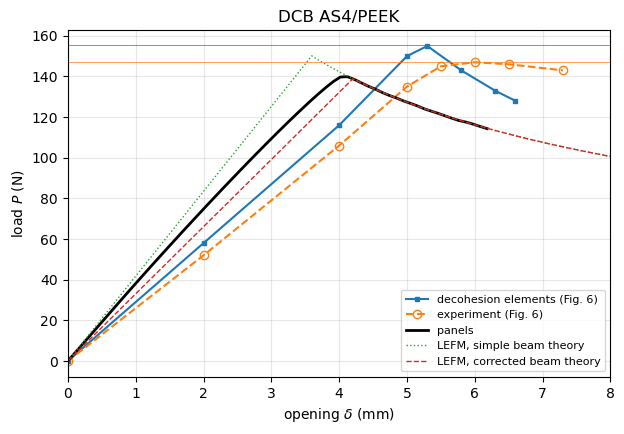

panels: 60 openings, 0 bisections, crack growth 8.2 mm


In [6]:
fe = fe_cases[key]
ex = exp_tests['DCB_AS4PEEK_Reeder_Crews_1990']
case, res = runs[key]
rows = dict(fe['curves'])
rows.update(ex['curves'])
rows['panels'] = (np.concatenate(([0.], res['delta'])), np.concatenate(([0.], res['P'])))
rows['LEFM, simple beam theory'] = du.lefm_curve(fe, fe['a0'] + 40)
rows['LEFM, corrected beam theory'] = du.lefm_curve(fe, fe['a0'] + 40, corrected=True)
display(Markdown(du.markdown_table(rows, ref=['decohesion elements (Fig. 6)', 'experiment (Fig. 6)'])))
Pp = res['P'].max()
display(Markdown(f"Peak loads of Table 3: FE {fe['Pmax']} N, experiment {ex['Pmax']} N; "
                 f"panels {Pp:.1f} N ({100*(Pp/fe['Pmax'] - 1):+.1f}% vs FE, "
                 f"{100*(Pp/ex['Pmax'] - 1):+.1f}% vs experiment)."))
fig, ax = plt.subplots(figsize=(7, 4.5))
style = {'experiment (Fig. 6)': dict(ls='--', marker='o', mfc='none'),
         'decohesion elements (Fig. 6)': dict(marker='s', ms=3),
         'panels': dict(lw=2, color='k'),
         'LEFM, simple beam theory': dict(ls=':', lw=1),
         'LEFM, corrected beam theory': dict(ls='--', lw=1)}
du.plot_curves(ax, rows, style)
ax.axhline(fe['Pmax'], color='C0', lw=0.5)
ax.axhline(ex['Pmax'], color='C1', lw=0.5)
ax.set_xlim(0, max(8, res['delta'].max()*1.1))
ax.set_title(fe['label'])
plt.show()
print(f"panels: {len(res['delta'])} openings, {res['failed']} bisections, "
      f"crack growth {res['a'][-1] - fe['a0']:.1f} mm")


**Remarks.**

- The penalty stiffness $K = 10^6$ N/mm$^3$ of the paper is replaced by $10^5$ N/mm$^3$ (see above).
- The FE model uses solid elements (3D, 4 decohesion elements across the width); panels uses CLPT plates, without transverse shear deformation.
- The digitised curves are approximate; the peak loads of Table 3 are exact.

## Discussion

- **Peak load.** panels predicts 139.9 N at an opening of 4.12 mm, 4.9% below the experimental peak (147.1 N) and 9.9% below the FE peak (155.3 N) of Table 3, and within 0.7% of the corrected beam theory (138.9 N).
- **Mesh of the FE model.** The FE model has 102 decohesion elements along 102 mm, about 1 mm each, while the cohesive zone length is about 1.35 mm ($l_{cz} = 0.88\,E_2 G_{Ic}/N^2$). With about one element in the cohesive zone, cohesive FE models overpredict the peak load (Turon et al. 2007, Figs. 5 and 8), which is consistent with the FE peak being above the experiment and above both beam theories.
- **Initial stiffness.** panels (37.5 N/mm) lies between the simple (41.8 N/mm) and the corrected (33.0 N/mm) beam theories. The FE (about 29 N/mm) and experimental (about 26 N/mm) curves of Fig. 6 are 12-21% more compliant than the corrected beam theory. That difference is larger than the effect of transverse shear and root rotation, which suggests that the displacement plotted in the paper includes compliance that no beam model has, e.g. of the loading hinges, or a different definition of the displacement. This is a hypothesis; the paper does not give enough detail to confirm it, so the openings at the peak are not compared.
- **After the peak.** The crack grew 8.2 mm in the panels run. The experimental curve decreases more slowly than the models because of fibre bridging, as discussed by the authors.
- **Robustness.** The run converged at every opening without bisection.